# Import library

In [17]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root_dir)

In [18]:
import torchgeo
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from torchgeo.trainers import SemanticSegmentationTask
from torch.utils.data import Dataset, DataLoader
import rasterio
from rasterio.windows import Window
from tqdm.auto import tqdm

# Load model from checkpoint

In [19]:
image_path = '../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff'

In [20]:
from typing import Any

import kornia.augmentation as K
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import torch.nn as nn
from matplotlib.figure import Figure
from torch import Tensor
from torchmetrics import MetricCollection
from torchmetrics import Accuracy, JaccardIndex, MetricCollection
from torchvision.models._api import WeightsEnum


class CustomSegmentationTask(SemanticSegmentationTask):
    def __init__(self,**kwargs):
        # Remove 'ignore' parameter if it exists in kwargs
        if 'ignore' in kwargs:
            del kwargs['ignore']
        super().__init__(**kwargs)

    def configure_losses(self) -> None:
        """Initialize the loss criterion."""
        ignore_index: int | None = self.hparams['ignore_index']
        match self.hparams['loss']:
            case 'ce':
                ignore_value = -1000 if ignore_index is None else ignore_index
                self.criterion: nn.Module = nn.CrossEntropyLoss(
                    ignore_index=ignore_value, weight=self.hparams['class_weights']
                )
            case 'bce':
                self.criterion = nn.BCEWithLogitsLoss()
            case 'jaccard':
                # JaccardLoss requires a list of classes to use instead of a class
                # index to ignore.
                classes = [
                    i for i in range(self.hparams['num_classes']) if i != ignore_index
                ]

                self.criterion = smp.losses.JaccardLoss(
                    mode='binary'
                )
            case 'focal':
                self.criterion = smp.losses.FocalLoss(
                    'binary', ignore_index=ignore_index, normalized=True
                )
    def configure_metrics(self) -> None:
        """Initialize the performance metrics.

        * :class:`~torchmetrics.Accuracy`: Overall accuracy
          (OA) using 'micro' averaging. The number of true positives divided by the
          dataset size. Higher values are better.
        * :class:`~torchmetrics.JaccardIndex`: Intersection
          over union (IoU). Uses 'micro' averaging. Higher valuers are better.

        .. note::
           * 'Micro' averaging suits overall performance evaluation but may not reflect
             minority class accuracy.
           * 'Macro' averaging, not used here, gives equal weight to each class, useful
             for balanced performance assessment across imbalanced classes.
        """
        kwargs = {
            'task': 'binary',
            'num_classes': self.hparams['num_classes'],
            'num_labels': None,
            'ignore_index': self.hparams['ignore_index'],
        }
        metrics = MetricCollection(
            [
                Accuracy(multidim_average='global', average='micro', **kwargs),
                JaccardIndex(average='micro', **kwargs),
            ]
        )
        self.train_metrics = metrics.clone(prefix='train_')
        self.val_metrics = metrics.clone(prefix='val_')
        self.test_metrics = metrics.clone(prefix='test_')

    def training_step(
        self, batch: Any, batch_idx: int, dataloader_idx: int = 0
    ) -> Tensor:
        """Compute the training loss and additional metrics.

        Args:
            batch: The output of your DataLoader.
            batch_idx: Integer displaying index of this batch.
            dataloader_idx: Index of the current dataloader.

        Returns:
            The loss tensor.
        """
        x = batch['image']
        y = batch['mask']
        batch_size = x.shape[0]
        y_hat = self(x).squeeze(1)
        self.train_metrics(y_hat, y)
        self.log_dict(self.train_metrics, batch_size=batch_size)

        if self.hparams['loss'] == 'bce':
            y = y.float()

        loss: Tensor = self.criterion(y_hat, y)
        self.log('train_loss', loss, batch_size=batch_size)

        return loss
    
    def validation_step(
        self, batch: Any, batch_idx: int, dataloader_idx: int = 0
    ) -> None:
        """Compute the validation loss and additional metrics.

        Args:
            batch: The output of your DataLoader.
            batch_idx: Integer displaying index of this batch.
            dataloader_idx: Index of the current dataloader.
        """
        x = batch['image']
        y = batch['mask']
        batch_size = x.shape[0]
        y_hat = self(x).squeeze(1)
        self.val_metrics(y_hat, y)
        self.log_dict(self.val_metrics, batch_size=batch_size)

        if self.hparams['loss'] == 'bce':
            y = y.float()

        loss = self.criterion(y_hat, y)
        self.log('val_loss', loss, batch_size=batch_size)
    
    def test_step(self, batch: Any, batch_idx: int, dataloader_idx: int = 0) -> None:
        """Compute the test loss and additional metrics.

        Args:
            batch: The output of your DataLoader.
            batch_idx: Integer displaying index of this batch.
            dataloader_idx: Index of the current dataloader.
        """
        x = batch['image']
        y = batch['mask']
        batch_size = x.shape[0]
        y_hat = self(x).squeeze(1)
        self.test_metrics(y_hat, y)
        self.log_dict(self.test_metrics, batch_size=batch_size)

        if self.hparams['loss'] == 'bce':
            y = y.float()

        loss = self.criterion(y_hat, y)
        self.log('test_loss', loss, batch_size=batch_size)

In [22]:
# Path to your checkpoint file
checkpoint_path = "../notebooks/lightning_logs/pugs_detection/version_19/checkpoints/epoch=18-val_loss=0.27.ckpt"

# Direct loading with the correct channel count
model = CustomSegmentationTask.load_from_checkpoint(
    checkpoint_path,
    in_channels=13  # Match what's in the checkpoint
)

In [10]:
# trainer.test(model=model, dataloaders=test_loader)

# Predict whole area

In [11]:
# Use custom collate function to maintain window_ifo as list of tuples
# so we can easily extract the window coordinates
def custom_collate_fn(batch):
    """Keep window coordinates as a list of tuples instead of tensors"""
    images = torch.stack([torch.from_numpy(item["image"]) for item in batch])
    window_infos = [item["window_info"] for item in batch]
    
    return {
        "image": images,
        "window_info": window_infos
    }

In [23]:
# band_list_predict = [0,1,2,3,4,5,6,7,8,9,10,11,12,13] # 13 is osm binary mask
# band_list_predict = [0,1,2,3,4,5,6,7,8,9,10,11,12] # 13 is osm binary mask
# band_list_predict = [1,2,3,4,5,6,7,11,12,13]
band_list_predict = [0,1,2,3,4,5,6,7,8,9,10,11,12]

In [24]:
class LargeImageDataset(Dataset):
    def __init__(self, image_path, patch_size=256, stride=256, band_list=None):
        self.image_path = image_path
        self.patch_size = patch_size
        self.stride = stride
        self.band_list = band_list
        
        # Open the image to get dimensions
        with rasterio.open(image_path) as src:
            self.height = src.height
            self.width = src.width
            self.count = src.count
            self.transform = src.transform
            self.crs = src.crs

        # Create list of windows - all using Window objects
        self.windows = []
        for y in range(0, self.height - patch_size + 1, stride):
            for x in range(0, self.width - patch_size + 1, stride):
                self.windows.append(Window(x, y, patch_size, patch_size))

        # Edge patches along bottom
        if self.height % stride != 0:
            last_y = self.height - patch_size
            for x in range(0, self.width - patch_size + 1, stride):
                self.windows.append(Window(x, last_y, patch_size, patch_size))

        # Edge patches along right side
        if self.width % stride != 0:
            last_x = self.width - patch_size
            for y in range(0, self.height - patch_size + 1, stride):
                self.windows.append(Window(last_x, y, patch_size, patch_size))

        # Corner patch (if needed)
        if self.width % stride != 0 and self.height % stride != 0:
            self.windows.append(Window(self.width - patch_size, 
                                    self.height - patch_size,
                                    patch_size, patch_size))
               
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        window = self.windows[idx]
        
        with rasterio.open(self.image_path) as src:
            # Read image data for this window
            image = src.read(window=window)
            # image = image[0:14, :, :]  # Select specific bands
            image = image[self.band_list, :, :] # Select specific bands
            if(image.shape[0] > len(self.band_list)):
                image = image.squeeze(0)           
    
        return {
            "image": image,
            "window_info": window  # Store coordinates as tuple
        }

In [25]:
file_output_path = '../reports/prediction_results_track/whole_area_prediction/6_new_model_task/prediction_binary_dn_osm_v19.tif'

In [26]:
inference_dataset = LargeImageDataset(image_path, patch_size=256, stride=256, band_list=band_list_predict)
# Regular DataLoader WITH custom collate function
inference_loader = DataLoader(
    inference_dataset, 
    batch_size=4, 
    num_workers=4,
    collate_fn=custom_collate_fn  # Use our custom collate
)

# Create output array
prediction_map = np.zeros((inference_dataset.height, inference_dataset.width), dtype=np.float32)
counts = np.zeros((inference_dataset.height, inference_dataset.width), dtype=np.float32)

# Process all patches
model.eval()
with torch.no_grad():
    for batch in tqdm(inference_loader):
        # Get images and window info
        images = batch["image"].to(model.device)
        windows = batch["window_info"]
        
        # Run inference
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        
        # Process each patch in the batch
        # Process each patch in the batch
        for i, window in enumerate(windows):
            # Get window coordinates
            x_off = window.col_off
            y_off = window.row_off
            width = window.width
            height = window.height
            
            # Get prediction for this patch
            pred = probs[i].squeeze().cpu().numpy()
            # Ensure prediction is 2D for plotting
            if pred.ndim > 2:
                if pred.shape[0] == 1:
                    # Single channel but in shape (1, H, W)
                    pred = pred.squeeze(0)
                else:
                    pred = pred[1]
            # Add to output array
            prediction_map[y_off:y_off+height, x_off:x_off+width] += pred
            counts[y_off:y_off+height, x_off:x_off+width] += 1

# Average overlapping predictions
with np.errstate(divide='ignore', invalid='ignore'):
    prediction_map = np.divide(prediction_map, counts)
    prediction_map = np.nan_to_num(prediction_map)

    # Apply threshold to get binary predictions (0 or 1)
    prediction_map = (prediction_map > 0.5).astype(np.float32)

# Save the prediction
with rasterio.open(
    file_output_path, 
    'w',
    driver='GTiff',
    height=inference_dataset.height,
    width=inference_dataset.width,
    count=1,
    dtype=rasterio.float32,
    crs=inference_dataset.crs,
    transform=inference_dataset.transform
) as dst:
    dst.write(prediction_map[np.newaxis, :, :])

100%|██████████| 25/25 [00:07<00:00,  3.35it/s]


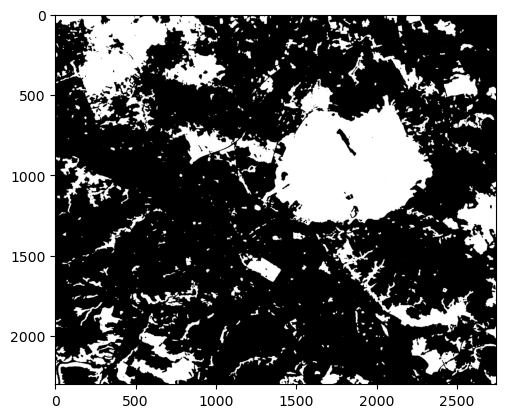

In [27]:
open_image = rasterio.open(file_output_path)
image = open_image.read(1)
plt.imshow(image, cmap='gray')
open_image.close()